In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ssn

In [3]:
sales=pd.read_csv("amazon_sales_data 2025.csv")
sales.head()


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [4]:
sales.columns

Index(['Order ID', 'Date', 'Product', 'Category', 'Price', 'Quantity',
       'Total Sales', 'Customer Name', 'Customer Location', 'Payment Method',
       'Status'],
      dtype='object')

In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB


In [7]:
sales.describe()

,Price,Quantity,Total Sales
count,250.000000,250.000000,250.000000
mean,343.580000,2.856000,975.380000
std,380.635808,1.429489,1252.112254
min,15.000000,1.000000,15.000000
25%,40.000000,2.000000,100.000000
50%,150.000000,3.000000,400.000000
75%,600.000000,4.000000,1500.000000
max,1200.000000,5.000000,6000.000000


In [9]:
sales.describe(include = ["object"])

,Order ID,Date,Product,Category,Customer Name,Customer Location,Payment Method,Status
count,250,250,250,250,250,250,250,250
unique,250,60,10,5,10,10,5,3
top,ORD0001,10-02-25,Smartphone,Electronics,Emma Clark,Houston,PayPal,Completed
freq,1,10,35,118,32,32,60,88


In [13]:
sales['Category'].value_counts()

Category
Electronics        118
Home Appliances     40
Clothing            40
Footwear            27
Books               25
Name: count, dtype: int64

In [26]:
sales['Customer Name'].value_counts()

Customer Name
Emma Clark       32
Jane Smith       30
Olivia Wilson    29
David Lee        26
John Doe         26
Michael Brown    24
Daniel Harris    23
Emily Johnson    22
Chris White      22
Sophia Miller    16
Name: count, dtype: int64

In [14]:
sales['Product'].value_counts().keys

<bound method Series.keys of Product
Smartphone         35
Smartwatch         34
Running Shoes      27
Headphones         25
Book               25
Laptop             24
Refrigerator       24
T-Shirt            20
Jeans              20
Washing Machine    16
Name: count, dtype: int64>

In [43]:
sales['Customer Location'].value_counts()

Customer Location
Houston          32
Miami            31
Dallas           29
New York         26
Boston           26
Denver           26
Chicago          22
Seattle          22
San Francisco    19
Los Angeles      17
Name: count, dtype: int64

In [15]:
sales["Payment Method"].value_counts(normalize = True)

Payment Method
PayPal         0.240
Credit Card    0.216
Debit Card     0.212
Gift Card      0.168
Amazon Pay     0.164
Name: proportion, dtype: float64

In [21]:
sales.sort_values(by='Total Sales',ascending=False).head(10)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
92,ORD0093,06-03-25,Refrigerator,Home Appliances,1200,5,6000,David Lee,Denver,PayPal,Cancelled
125,ORD0126,04-02-25,Refrigerator,Home Appliances,1200,5,6000,Olivia Wilson,Chicago,Gift Card,Pending
68,ORD0069,25-02-25,Refrigerator,Home Appliances,1200,4,4800,David Lee,Boston,Gift Card,Pending
73,ORD0074,25-03-25,Refrigerator,Home Appliances,1200,4,4800,Jane Smith,Dallas,Gift Card,Cancelled
63,ORD0064,13-02-25,Refrigerator,Home Appliances,1200,4,4800,Emily Johnson,Denver,PayPal,Pending
21,ORD0022,07-03-25,Refrigerator,Home Appliances,1200,4,4800,Olivia Wilson,Houston,Credit Card,Pending
154,ORD0155,05-02-25,Refrigerator,Home Appliances,1200,4,4800,Sophia Miller,Seattle,Credit Card,Pending
167,ORD0168,24-03-25,Laptop,Electronics,800,5,4000,Michael Brown,Miami,Debit Card,Pending
61,ORD0062,10-02-25,Laptop,Electronics,800,5,4000,Olivia Wilson,San Francisco,PayPal,Completed
119,ORD0120,16-02-25,Laptop,Electronics,800,5,4000,Emily Johnson,Denver,PayPal,Completed


In [22]:
sales.sort_values(by=['Product','Category'],ascending=False).head(10)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
13,ORD0014,04-03-25,Washing Machine,Home Appliances,600,3,1800,Michael Brown,Miami,Credit Card,Cancelled
25,ORD0026,14-02-25,Washing Machine,Home Appliances,600,1,600,Olivia Wilson,Boston,Debit Card,Cancelled
29,ORD0030,10-02-25,Washing Machine,Home Appliances,600,3,1800,Emily Johnson,Dallas,Gift Card,Cancelled
75,ORD0076,24-02-25,Washing Machine,Home Appliances,600,1,600,Jane Smith,Dallas,Amazon Pay,Completed
82,ORD0083,28-02-25,Washing Machine,Home Appliances,600,4,2400,Emma Clark,Houston,Gift Card,Cancelled
98,ORD0099,18-02-25,Washing Machine,Home Appliances,600,5,3000,Michael Brown,Seattle,Debit Card,Completed
111,ORD0112,06-03-25,Washing Machine,Home Appliances,600,2,1200,David Lee,Dallas,Gift Card,Cancelled
150,ORD0151,29-03-25,Washing Machine,Home Appliances,600,4,2400,Jane Smith,Los Angeles,Amazon Pay,Pending
159,ORD0160,06-02-25,Washing Machine,Home Appliances,600,3,1800,Olivia Wilson,Denver,Gift Card,Cancelled
165,ORD0166,30-03-25,Washing Machine,Home Appliances,600,4,2400,Chris White,Houston,Credit Card,Pending


In [23]:
sales.sort_values(by=['Customer Name','Product'],ascending=False).head(10)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
8,ORD0009,08-03-25,T-Shirt,Clothing,20,3,60,Sophia Miller,Boston,PayPal,Completed
136,ORD0137,20-03-25,Smartwatch,Electronics,150,3,450,Sophia Miller,San Francisco,Debit Card,Completed
152,ORD0153,23-02-25,Smartwatch,Electronics,150,5,750,Sophia Miller,San Francisco,PayPal,Pending
7,ORD0008,02-03-25,Smartphone,Electronics,500,1,500,Sophia Miller,Miami,PayPal,Completed
28,ORD0029,12-02-25,Smartphone,Electronics,500,1,500,Sophia Miller,Denver,Credit Card,Cancelled
141,ORD0142,15-03-25,Smartphone,Electronics,500,3,1500,Sophia Miller,Miami,Gift Card,Completed
156,ORD0157,08-02-25,Smartphone,Electronics,500,3,1500,Sophia Miller,Denver,Credit Card,Pending
79,ORD0080,23-02-25,Running Shoes,Footwear,60,4,240,Sophia Miller,San Francisco,Debit Card,Pending
189,ORD0190,23-02-25,Running Shoes,Footwear,60,1,60,Sophia Miller,Houston,PayPal,Completed
35,ORD0036,09-02-25,Refrigerator,Home Appliances,1200,2,2400,Sophia Miller,Boston,PayPal,Cancelled


In [27]:
sales.apply(np.max)


Order ID                     ORD0250
Date                        31-03-25
Product              Washing Machine
Category             Home Appliances
Price                           1200
Quantity                           5
Total Sales                     6000
Customer Name          Sophia Miller
Customer Location            Seattle
Payment Method                PayPal
Status                       Pending
dtype: object

In [30]:
pd.crosstab(sales["Payment Method"],sales["Status"])

Status,Cancelled,Completed,Pending
Payment Method,,,
Amazon Pay,7,21,13
Credit Card,16,17,21
Debit Card,20,14,19
Gift Card,18,6,18
PayPal,16,30,14


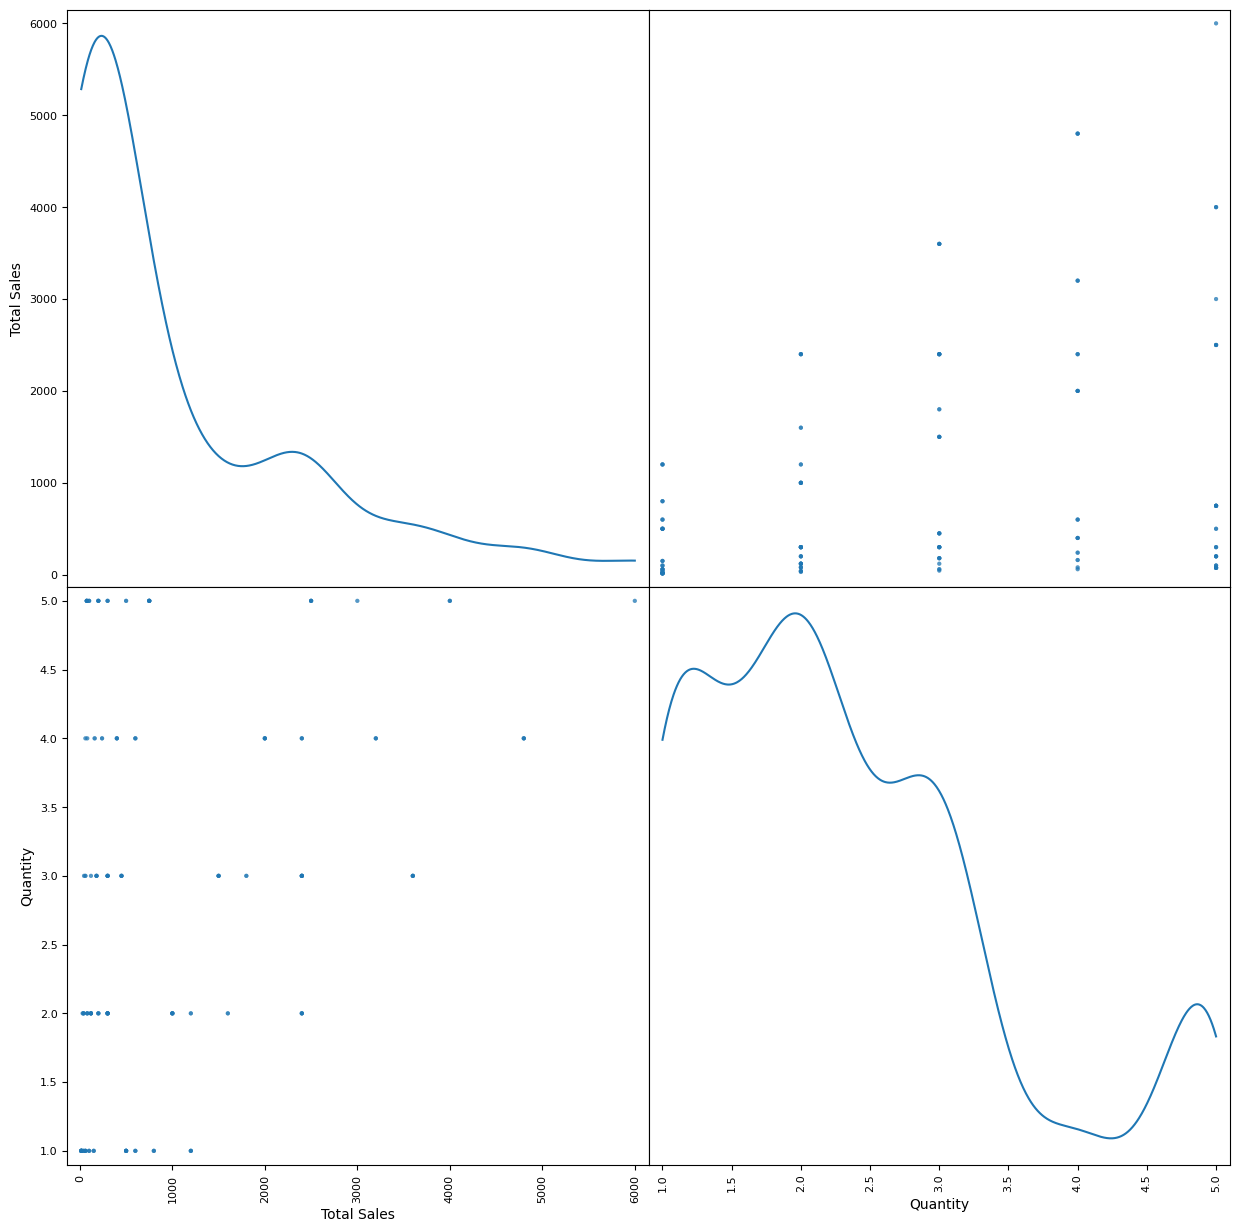

In [32]:
pd.plotting.scatter_matrix(
    sales[["Total Sales", "Quantity"]],
    figsize = (15, 15),
    diagonal = "kde")
plt.show()

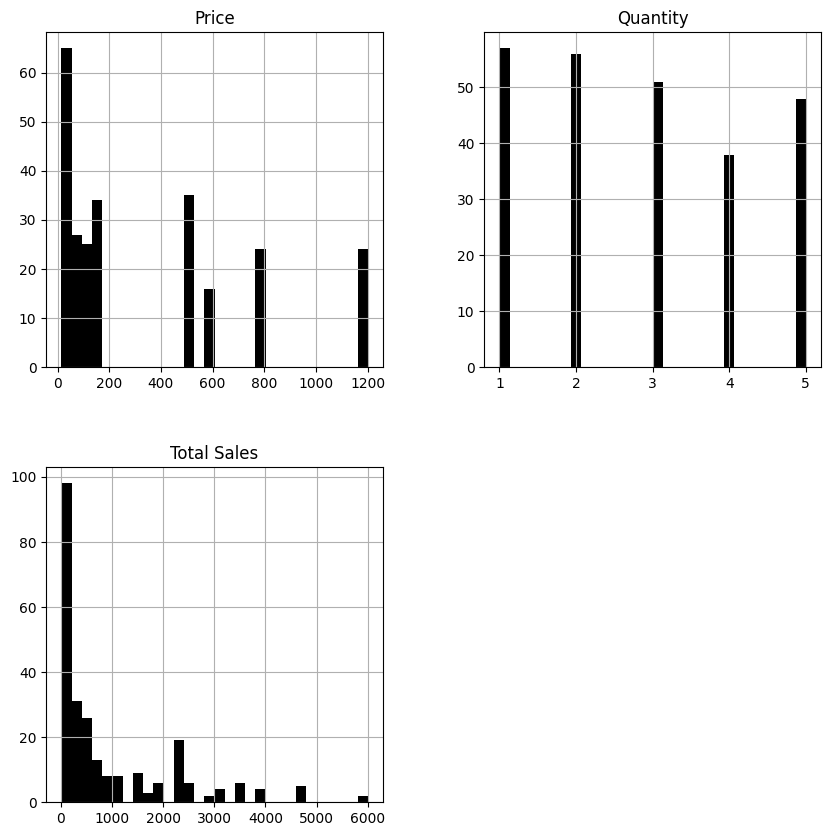

In [34]:
sales.hist(color = "k",
        bins = 30,
        figsize = (10, 10))
plt.show()

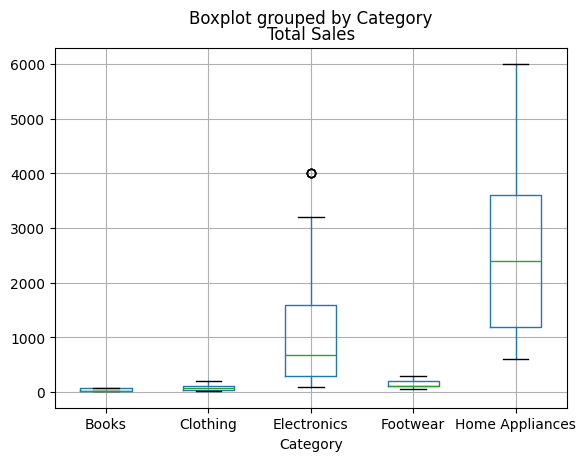

In [40]:
sales.boxplot(column = "Total Sales",by="Category")
plt.show()

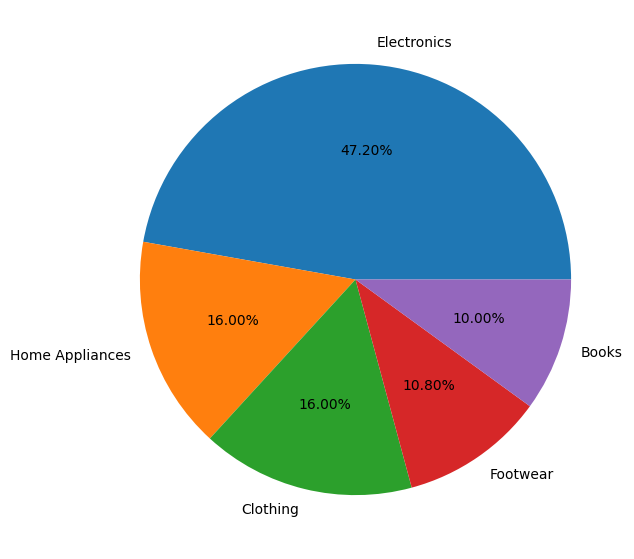

In [42]:
plt.figure(figsize=(7,7))
plt.pie(list(sales['Category'].value_counts()),
        labels=list(sales['Category'].value_counts().keys()),
        autopct='%0.2f%%')
plt.show()

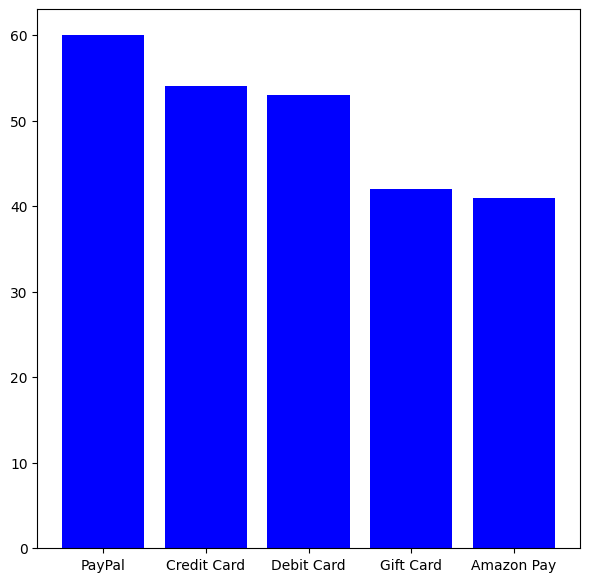

In [44]:
plt.figure(figsize=(7,7))
plt.bar(list(sales['Payment Method'].value_counts().keys()),
        list(sales['Payment Method'].value_counts()),
        color=['b'])
plt.show()